<a href="https://colab.research.google.com/github/NishigandhaChoudhury/Neural-Network-and-Deep-Learning-Lab-Experiments/blob/main/NNDLLAB14(12).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

actual exp 12

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

            temperature
date                   
2020-01-01    20.745071
2020-01-02    20.677539
2020-01-03    22.714067
2020-01-04    24.831196
2020-01-05    22.922241
2020-01-06    23.551343
2020-01-07    26.786514
2020-01-08    25.958838
2020-01-09    24.362536
2020-01-10    26.008642

Total days : 1460
Temp range : -1.8°C  to  43.0°C


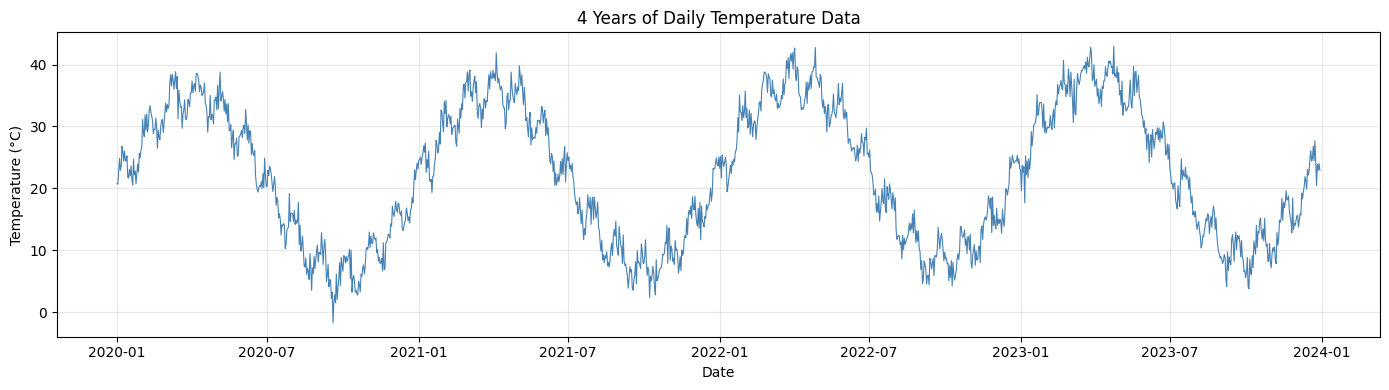

In [ ]:
np.random.seed(42)

days   = 365 * 4          # 4 years of daily data = 1460 days
time   = np.arange(days)

# Realistic temperature: seasonal sine wave + trend + noise
temperature = (
    20                                          # base temp
    + 15 * np.sin(2 * np.pi * time / 365)      # yearly season
    + 3  * np.sin(2 * np.pi * time / 30)       # monthly variation
    + 0.003 * time                              # slight warming trend
    + np.random.normal(0, 1.5, days)            # daily noise
)

# Put into a DataFrame
dates = pd.date_range(start="2020-01-01", periods=days, freq="D")
df    = pd.DataFrame({"date": dates, "temperature": temperature})
df.set_index("date", inplace=True)

print(df.head(10))
print(f"\nTotal days : {len(df)}")
print(f"Temp range : {df.temperature.min():.1f}°C  to  "
      f"{df.temperature.max():.1f}°C")

# Plot full dataset
plt.figure(figsize=(14, 4))
plt.plot(df.index, df.temperature, linewidth=0.8, color='steelblue')
plt.title("4 Years of Daily Temperature Data")
plt.xlabel("Date"); plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
WINDOW = 30    # use past 30 days to predict next day

# Normalize to [0, 1]
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[["temperature"]])  # shape (1460, 1)

# Build sliding window sequences
X, y = [], []
for i in range(len(scaled) - WINDOW):
    X.append(scaled[i : i + WINDOW])      # 30 days input
    y.append(scaled[i + WINDOW])          # next day target

X = np.array(X)   # shape: (1430, 30, 1)
y = np.array(y)   # shape: (1430, 1)

# Train / validation / test split  (70 / 15 / 15)
train_end = int(len(X) * 0.70)
val_end   = int(len(X) * 0.85)

X_train, y_train = X[:train_end],          y[:train_end]
X_val,   y_val   = X[train_end:val_end],   y[train_end:val_end]
X_test,  y_test  = X[val_end:],            y[val_end:]

print(f"X_train : {X_train.shape}")   # (1001, 30, 1)
print(f"X_val   : {X_val.shape}")     # (214,  30, 1)
print(f"X_test  : {X_test.shape}")    # (215,  30, 1)

X_train : (1000, 30, 1)
X_val   : (215, 30, 1)
X_test  : (215, 30, 1)


In [ ]:
model = models.Sequential([

    # First LSTM layer — return sequences so second LSTM gets full output
    layers.LSTM(64, activation='tanh',
                return_sequences=True,
                input_shape=(WINDOW, 1)),
    layers.Dropout(0.2),

    # Second LSTM layer — deeper memory
    layers.LSTM(32, activation='tanh',
                return_sequences=False),
    layers.Dropout(0.2),

    # Output: predict one temperature value
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Stop early if validation loss stops improving
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0362 - val_loss: 0.0090
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0093 - val_loss: 0.0125
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0081 - val_loss: 0.0078
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0078 - val_loss: 0.0088
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0077 - val_loss: 0.0050
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0080 - val_loss: 0.0095
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0065 - val_loss: 0.0044
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0066 - val_loss: 0.0115
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0066 - val_loss: 0.0039
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0058 - val_loss: 0.0076

Training stopped at epoch 10


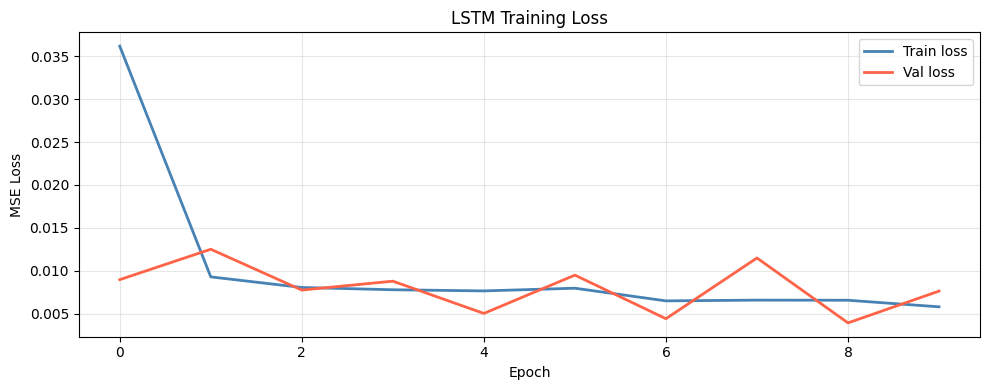

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train loss',
         color='steelblue', linewidth=2)
plt.plot(history.history['val_loss'], label='Val loss',
         color='tomato', linewidth=2)
plt.title('LSTM Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# Predict on test set
y_pred_scaled = model.predict(X_test, verbose=0)

# Denormalize back to °C
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test)

# Calculate metrics
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("=" * 40)
print(f"  MAE   (Mean Absolute Error) : {mae:.3f} °C")
print(f"  RMSE  (Root Mean Sq. Error) : {rmse:.3f} °C")
print(f"  MAPE  (Mean Abs % Error)    : {mape:.2f} %")
print("=" * 40)
print("\nInterpretation:")
print(f"  On average the model is off by {mae:.2f}°C per day")
print(f"  RMSE penalizes large spikes — {rmse:.2f}°C")

  MAE   (Mean Absolute Error) : 2.348 °C
  RMSE  (Root Mean Sq. Error) : 2.801 °C
  MAPE  (Mean Abs % Error)    : 18.30 %

Interpretation:
  On average the model is off by 2.35°C per day
  RMSE penalizes large spikes — 2.80°C


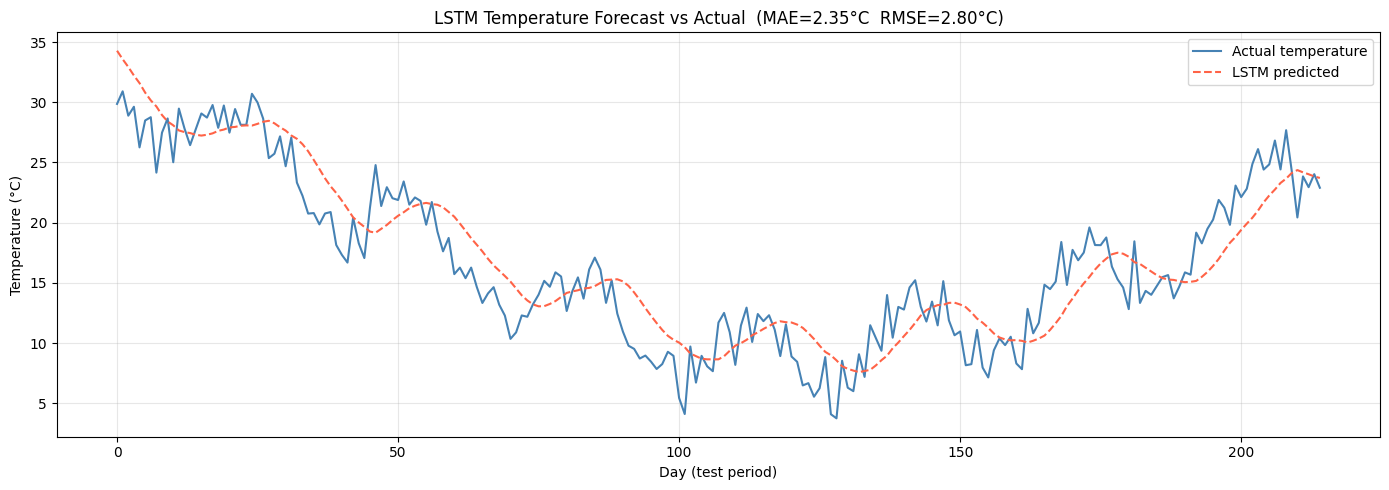

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(y_true,  label='Actual temperature',
         color='steelblue', linewidth=1.5)
plt.plot(y_pred,  label='LSTM predicted',
         color='tomato', linewidth=1.5, linestyle='--')
plt.title(f'LSTM Temperature Forecast vs Actual  '
          f'(MAE={mae:.2f}°C  RMSE={rmse:.2f}°C)')
plt.xlabel('Day (test period)')
plt.ylabel('Temperature (°C)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

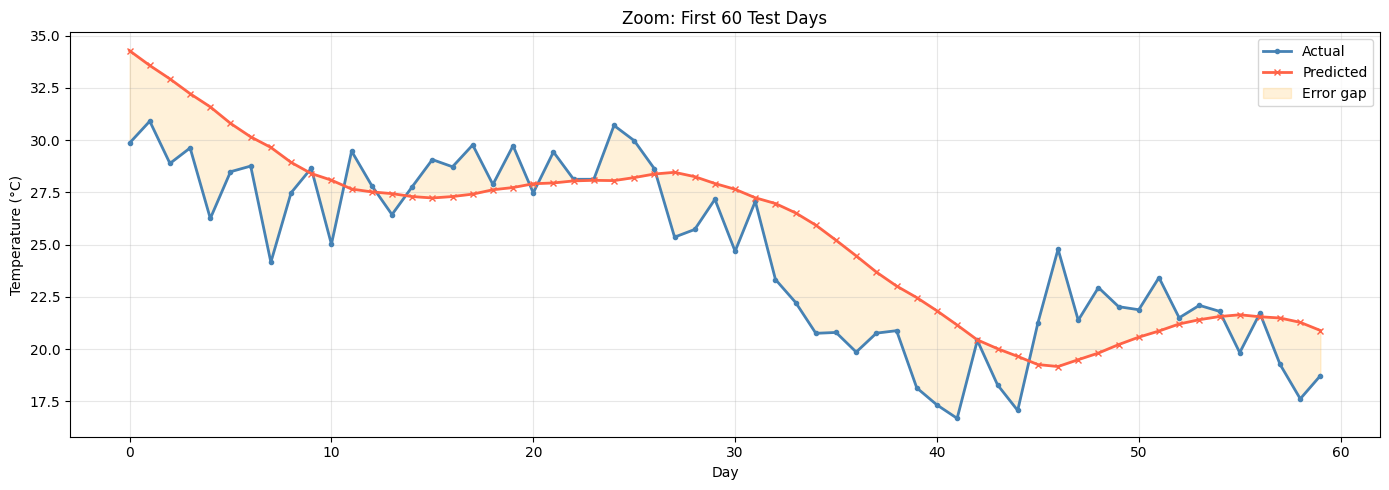

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(y_true[:60],  label='Actual',
         color='steelblue', linewidth=2, marker='o', markersize=3)
plt.plot(y_pred[:60],  label='Predicted',
         color='tomato', linewidth=2, marker='x', markersize=4)
plt.fill_between(range(60),
                 y_true[:60].flatten(),
                 y_pred[:60].flatten(),
                 alpha=0.15, color='orange',
                 label='Error gap')
plt.title('Zoom: First 60 Test Days')
plt.xlabel('Day'); plt.ylabel('Temperature (°C)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

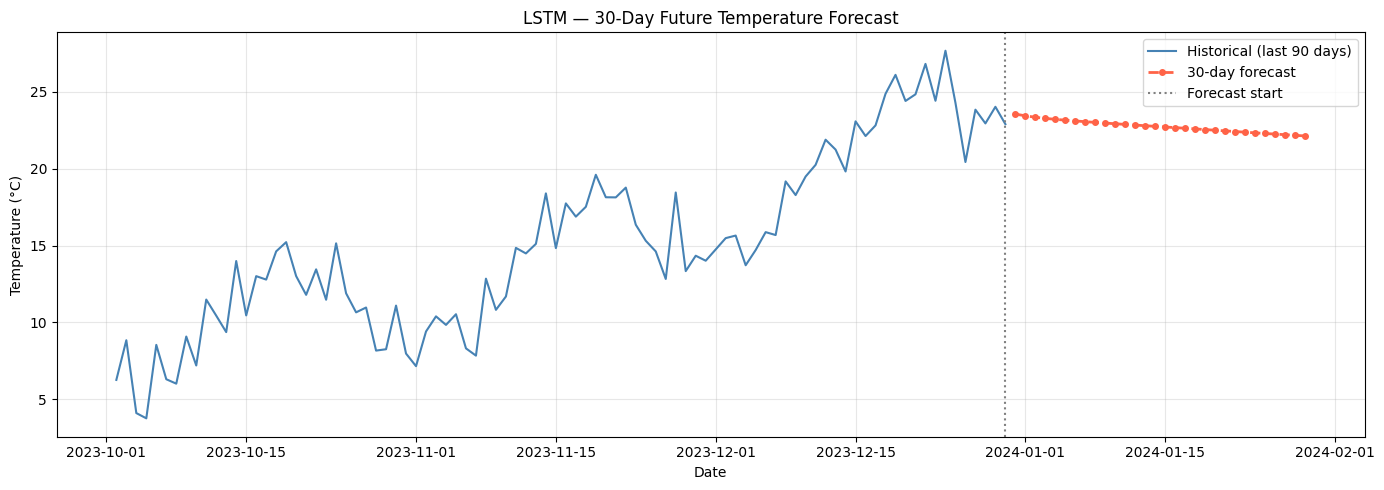


30-day forecast (°C):
  Day 01 | 2023-12-31 | 23.56°C
  Day 02 | 2024-01-01 | 23.44°C
  Day 03 | 2024-01-02 | 23.35°C
  Day 04 | 2024-01-03 | 23.28°C
  Day 05 | 2024-01-04 | 23.21°C
  Day 06 | 2024-01-05 | 23.16°C
  Day 07 | 2024-01-06 | 23.11°C
  Day 08 | 2024-01-07 | 23.06°C
  Day 09 | 2024-01-08 | 23.01°C
  Day 10 | 2024-01-09 | 22.97°C
  Day 11 | 2024-01-10 | 22.93°C
  Day 12 | 2024-01-11 | 22.88°C
  Day 13 | 2024-01-12 | 22.84°C
  Day 14 | 2024-01-13 | 22.80°C
  Day 15 | 2024-01-14 | 22.76°C
  Day 16 | 2024-01-15 | 22.71°C
  Day 17 | 2024-01-16 | 22.67°C
  Day 18 | 2024-01-17 | 22.63°C
  Day 19 | 2024-01-18 | 22.59°C
  Day 20 | 2024-01-19 | 22.55°C
  Day 21 | 2024-01-20 | 22.50°C
  Day 22 | 2024-01-21 | 22.46°C
  Day 23 | 2024-01-22 | 22.42°C
  Day 24 | 2024-01-23 | 22.38°C
  Day 25 | 2024-01-24 | 22.33°C
  Day 26 | 2024-01-25 | 22.29°C
  Day 27 | 2024-01-26 | 22.25°C
  Day 28 | 2024-01-27 | 22.21°C
  Day 29 | 2024-01-28 | 22.17°C
  Day 30 | 2024-01-29 | 22.13°C


In [ ]:
# Start from last known 30 days
last_window = scaled[-WINDOW:].reshape(1, WINDOW, 1)
future_preds = []

for _ in range(30):
    pred = model.predict(last_window, verbose=0)[0][0]
    future_preds.append(pred)
    # Slide window forward by 1
    last_window = np.append(
        last_window[:, 1:, :],
        [[[pred]]],
        axis=1
    )

# Denormalize
future_temps = scaler.inverse_transform(
    np.array(future_preds).reshape(-1, 1)
)

# Plot
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30, freq="D"
)

plt.figure(figsize=(14, 5))
plt.plot(df.index[-90:], df.temperature[-90:],
         label='Historical (last 90 days)',
         color='steelblue', linewidth=1.5)
plt.plot(future_dates, future_temps,
         label='30-day forecast',
         color='tomato', linewidth=2,
         linestyle='--', marker='o', markersize=4)
plt.axvline(x=df.index[-1], color='gray',
            linestyle=':', linewidth=1.5, label='Forecast start')
plt.title('LSTM — 30-Day Future Temperature Forecast')
plt.xlabel('Date'); plt.ylabel('Temperature (°C)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\n30-day forecast (°C):")
for i, (d, t) in enumerate(zip(future_dates, future_temps)):
    print(f"  Day {i+1:02d} | {d.strftime('%Y-%m-%d')} | {t[0]:.2f}°C")